In [25]:
import csv
import numpy as np


tr_in = np.genfromtxt('train_in.csv', delimiter=",")
ones = np.ones((len(tr_in),1))
tr_in = np.column_stack((tr_in, ones))
tr_out = np.genfromtxt('train_out.csv', delimiter=",")
te_in = np.genfromtxt('test_in.csv', delimiter=",")
ones2 = np.ones((len(te_in), 1))
te_in = np.column_stack((te_in, ones2))
te_out = np.genfromtxt('test_out.csv', delimiter=",")

classifier=np.zeros((10, 257))
#classifier=np.ones((10, 257))
#classifier=np.full((10, 257), 0.5)
#classifier=np.full((10, 257), 0.2)

In [26]:
def grcalc(data, labels, classifier):
    labels=np.array(labels, dtype=int)
      
    y=np.zeros((len(labels), 10))
    y[range(len(labels)), labels]=1
   
    pred=data@classifier.T
    
    error=pred-y

    gradient=2*(error.T@data)
           
    return gradient

In [27]:
def train(data, labels, classifier, alpha):
    
    gradient=grcalc(data, labels, classifier)

    sub=gradient*np.array(alpha)

    newp=classifier-sub

    return newp

In [28]:
def aloss(data, labels, classifier):
    
    labels=np.array(labels, dtype=int)
 
    y=np.zeros((len(labels), 10))
    y[range(len(labels)), labels]=1
    
    pred=data@classifier.T
    error=(pred-y)**2
    
    sumloss=np.sum(error)
    
    return sumloss/len(data)

In [29]:
def predict(data, classifier):
    
    curpred=data@classifier.T
    maxpred=np.argmax(curpred, axis=1)

    return maxpred

In [30]:
def acc(predict, labels):
    
    accu=np.sum(predict == labels)
    return accu*100/len(predict)

In [31]:
#Visualizing the network's performance on the training set and on the testing set

print("Visualizing the network's performance on both the sets")

print(f"Epoch 0:")

p=predict(tr_in, classifier)
p2=predict(te_in, classifier)
l=aloss(tr_in, tr_out, classifier)
l2=aloss(te_in, te_out, classifier)
a=acc(p, tr_out)
a2=acc(p2, te_out)
lr=4.8e-6 # here we set the learning rate
num_epochs=85
print(f"Training set - Average loss: {l}, Accuracy: {a:.2f}%")
print(f"Testing set - Average loss: {l2}, Accuracy: {a2:.2f}%")

newl=[l]
newa=[a]
newl2=[l2]
newa2=[a2]

for epoch in range(1, num_epochs+1):
    classifier = train(tr_in, tr_out, classifier, lr)
    p=predict(tr_in, classifier)
    p2=predict(te_in, classifier)
    newl.append(aloss(tr_in, tr_out, classifier))
    newa.append(acc(p, tr_out))
    newl2.append(aloss(te_in, te_out, classifier))
    newa2.append(acc(p2, te_out))

    print(f"\nEpoch {epoch}:")
    print(f"Training set - Average loss: {newl[epoch]}, Accuracy: {newa[epoch]:.2f}%")
    print(f"Testing set - Average loss: {newl2[epoch]}, Accuracy: {newa2[epoch]:.2f}%")

Visualizing the network's performance on both the sets
Epoch 0:
Training set - Average loss: 1.0, Accuracy: 18.69%
Testing set - Average loss: 1.0, Accuracy: 22.40%

Epoch 1:
Training set - Average loss: 0.7899089072427825, Accuracy: 34.15%
Testing set - Average loss: 0.8030248587383921, Accuracy: 33.80%

Epoch 2:
Training set - Average loss: 0.6752586394247052, Accuracy: 64.67%
Testing set - Average loss: 0.6932597569647306, Accuracy: 60.30%

Epoch 3:
Training set - Average loss: 0.6056702598098135, Accuracy: 60.11%
Testing set - Average loss: 0.6310132001647821, Accuracy: 56.10%

Epoch 4:
Training set - Average loss: 0.5589097836647228, Accuracy: 71.82%
Testing set - Average loss: 0.5882083770978491, Accuracy: 66.60%

Epoch 5:
Training set - Average loss: 0.524752237076038, Accuracy: 73.17%
Testing set - Average loss: 0.5588446301916151, Accuracy: 67.20%

Epoch 6:
Training set - Average loss: 0.49822972293274587, Accuracy: 77.15%
Testing set - Average loss: 0.5356196345948324, Accura

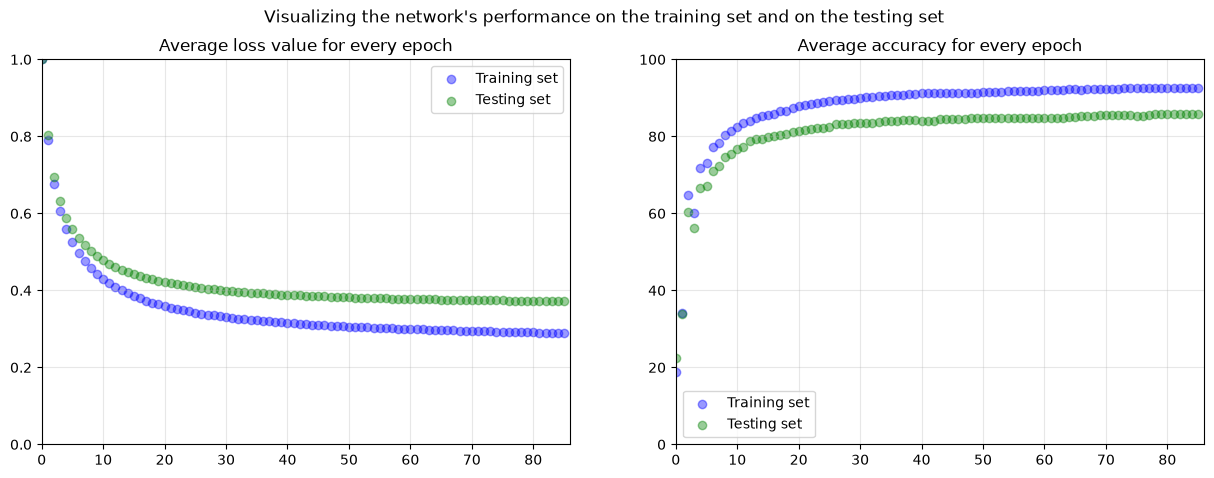

In [32]:
#Visualizing average loss and accuracy on training set and testing set

import matplotlib.pyplot as plt

fig1, ax1=plt.subplots(1, 2, figsize=(15,5))

epochs=list(range(len(newl)))
  
fig1.suptitle("Visualizing the network's performance on the training set and on the testing set")

ax1[0].set_xlim(right=num_epochs+1)
ax1[0].set_ylim(bottom=0, top=max(max(newl), max(newl2)))
ax1[0].scatter(epochs, newl, c="b", alpha=0.4, label="Training set")
ax1[0].scatter(epochs, newl2, c="g", alpha=0.4, label="Testing set")  
ax1[0].set_title('Average loss value for every epoch')
ax1[0].grid(True, alpha=0.3)
ax1[0].legend()


ax1[1].set_xlim(right=num_epochs+1)
ax1[1].set_ylim(bottom=0, top=100)
ax1[1].scatter(epochs, newa, c="b", alpha=0.4, label="Training set")
ax1[1].scatter(epochs, newa2, c="g", alpha=0.4, label="Testing set")
ax1[1].set_title('Average accuracy for every epoch')
ax1[1].grid(True, alpha=0.3)
ax1[1].legend()